In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

# Đọc dữ liệu đúng cách: bỏ dòng tiêu đề và xử lý giá trị '***'
df = pd.read_csv('GLB.Ts+dSST (1).csv', skiprows=1, na_values='***')
df.columns = [col.strip() for col in df.columns]

# Chuyển từng cột số sang kiểu numeric
auto_cols = [c for c in df.columns if c != 'Year']
for col in auto_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Làm sạch và chọn phạm vi 1880-2025
df = df.dropna(subset=['Year', 'J-D']).copy()
df['Year'] = df['Year'].astype(int)
df = df[df['Year'] <= 2025].reset_index(drop=True)

# Tạo các cột hỗ trợ cho phân tích
df['decade'] = (df['Year'] // 10) * 10
df['annual'] = df['J-D']
df['rolling_10'] = df['annual'].rolling(10, center=True, min_periods=10).mean()

# Hiển thị thông tin cơ bản
df.head()


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON,decade,annual,rolling_10
0,1880,-0.19,-0.25,-0.10,-0.17,-0.10,-0.22,-0.19,-0.11,-0.15,-0.24,-0.23,-0.19,-0.18,NaN,NaN,-0.12,-0.17,-0.21,1880,-0.18,NaN
1,1881,-0.20,-0.16,0.02,0.04,0.06,-0.19,0.01,-0.04,-0.16,-0.22,-0.19,-0.07,-0.09,-0.10,-0.18,0.04,-0.07,-0.19,1880,-0.09,NaN
2,1882,0.15,0.13,0.04,-0.16,-0.14,-0.23,-0.17,-0.08,-0.15,-0.24,-0.17,-0.37,-0.11,-0.09,0.07,-0.09,-0.16,-0.19,1880,-0.11,NaN
3,1883,-0.30,-0.37,-0.13,-0.18,-0.18,-0.07,-0.08,-0.14,-0.22,-0.11,-0.24,-0.12,-0.18,-0.20,-0.34,-0.16,-0.10,-0.19,1880,-0.18,NaN
4,1884,-0.13,-0.08,-0.37,-0.40,-0.34,-0.35,-0.31,-0.28,-0.27,-0.25,-0.34,-0.31,-0.29,-0.27,-0.11,-0.37,-0.31,-0.29,1880,-0.29,NaN


# Phân tích xu hướng nhiệt độ bất thường bề mặt Trái Đất (1880–2025)

- **Mục tiêu:** trả lời 5 câu hỏi phân tích và 2 câu hỏi dự đoán bằng Python.
- **Dữ liệu sử dụng:** cột `J-D` (nhiệt độ bất thường năm) và các mùa `DJF`, `MAM`, `JJA`, `SON`.
- **Ghi chú:** các giá trị `***` được chuyển thành `NaN` trước khi phân tích.

In [3]:
# 1. Khám phá dữ liệu ban đầu
"""
Trong ô này, ta kiểm tra:
- phạm vi năm (1880-2025)
- số dòng, số cột
- giá trị trung bình, min, max của cột J-D
- các giá trị thiếu (NaN)
"""

# In thông tin cơ bản về DataFrame
print('Số dòng:', df.shape[0])
print('Số cột:', df.shape[1])
print('Năm bắt đầu:', df['Year'].min())
print('Năm kết thúc:', df['Year'].max())
print('\nThông tin tổng quan về các cột:')
df.info()

# Tóm tắt thống kê cho các cột chính
print('\nThống kê cột J-D (nhiệt độ bất thường năm):')
print(df['J-D'].describe())

# Kiểm tra giá trị thiếu
print('\nSố giá trị thiếu theo cột:')
print(df.isna().sum())


Số dòng: 146
Số cột: 22
Năm bắt đầu: 1880
Năm kết thúc: 2025

Thông tin tổng quan về các cột:
<class 'pandas.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Year        146 non-null    int64  
 1   Jan         146 non-null    float64
 2   Feb         146 non-null    float64
 3   Mar         146 non-null    float64
 4   Apr         146 non-null    float64
 5   May         146 non-null    float64
 6   Jun         146 non-null    float64
 7   Jul         146 non-null    float64
 8   Aug         146 non-null    float64
 9   Sep         146 non-null    float64
 10  Oct         146 non-null    float64
 11  Nov         146 non-null    float64
 12  Dec         146 non-null    float64
 13  J-D         146 non-null    float64
 14  D-N         145 non-null    float64
 15  DJF         145 non-null    float64
 16  MAM         146 non-null    float64
 17  JJA         146 non-null    

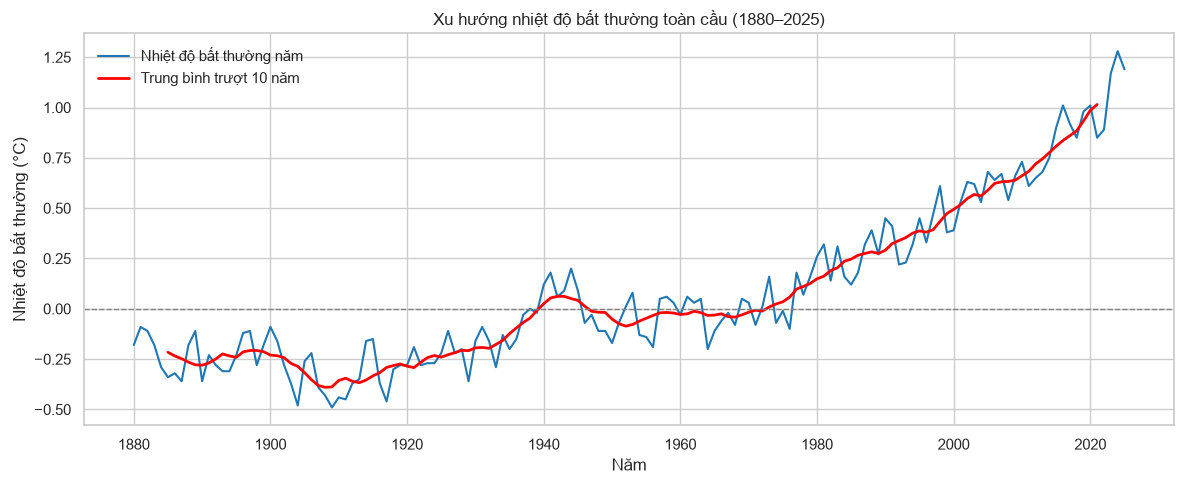

Giá trị năm 1880: -0.180
Giá trị năm 2025: 1.190
Thay đổi tổng từ 1880 đến 2025: 1.370°C
Xu hướng tăng trung bình mỗi năm: 0.008320°C/năm


In [6]:
# 2. Câu hỏi 1: Xu hướng trung bình toàn cầu từ 1880 đến 2025
"""
Mục đích: trả lời câu hỏi về sự thay đổi trung bình của nhiệt độ bất thường toàn cầu theo thời gian.
Ta sẽ vẽ đồ thị đường cho J-D và đường trung bình trượt 10 năm.
"""

# Vẽ đồ thị xu hướng năm
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['Year'], df['annual'], color='tab:blue', linewidth=1.5, label='Nhiệt độ bất thường năm')
ax.plot(df['Year'], df['rolling_10'], color='red', linewidth=2, label='Trung bình trượt 10 năm')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Xu hướng nhiệt độ bất thường toàn cầu (1880–2025)')
ax.set_xlabel('Năm')
ax.set_ylabel('Nhiệt độ bất thường (°C)')
ax.legend()
plt.tight_layout()
plt.show()

# Tính thay đổi từ đầu kỳ đến cuối kỳ
start = df.loc[df['Year'] == 1880, 'annual'].iloc[0]
end = df.loc[df['Year'] == 2025, 'annual'].iloc[0]
change = end - start
print(f'Giá trị năm 1880: {start:.3f}')
print(f'Giá trị năm 2025: {end:.3f}')
print(f'Thay đổi tổng từ 1880 đến 2025: {change:.3f}°C')

# Tính xu hướng tuyến tính theo năm
X = df['Year'].to_numpy().reshape(-1, 1)
y = df['annual'].to_numpy()
model = LinearRegression()
model.fit(X, y)
coef = model.coef_[0]
print(f'Xu hướng tăng trung bình mỗi năm: {coef:.6f}°C/năm')


Trung bình theo thập kỷ:
decade
1910   -0.333
1900   -0.317
1890   -0.241
1920   -0.240
1880   -0.216
1930   -0.123
1950   -0.047
1960   -0.031
1970    0.035
1940    0.042
1980    0.247
1990    0.387
2000    0.589
2010    0.808
2020    1.065
Name: annual, dtype: float64

Thập kỷ lạnh nhất: 1910s
Thập kỷ nóng nhất: 2020s


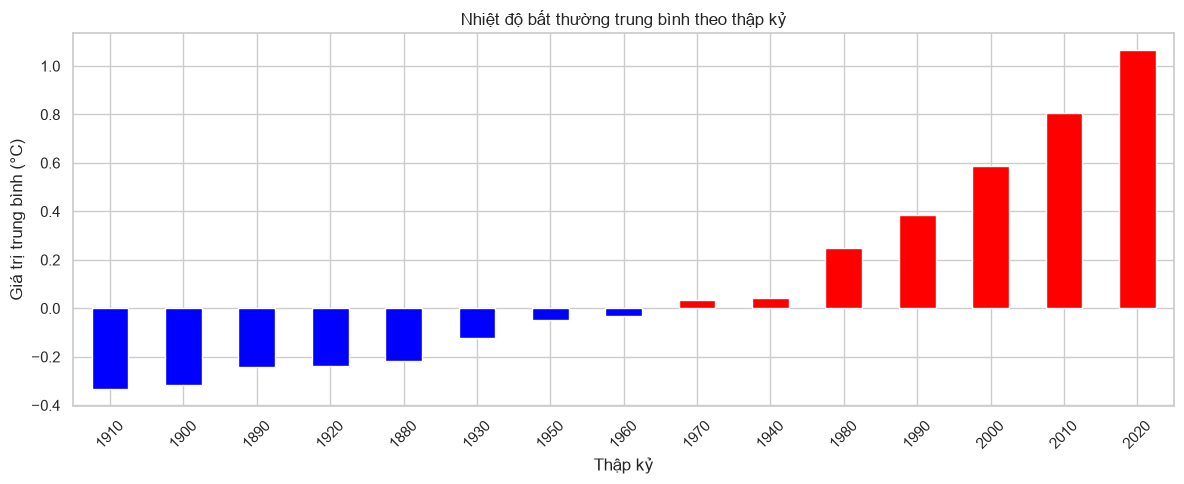

In [7]:
# 3. Câu hỏi 2: Thập kỷ nóng nhất và lạnh nhất
"""
Mục đích: xác định thập kỷ có giá trị nhiệt độ bất thường trung bình cao nhất và thấp nhất.
Ta dùng cột annual (J-D) và nhóm theo decade.
"""

# Tính trung bình theo thập kỷ
by_decade = df.groupby('decade')['annual'].mean().sort_values()
print('Trung bình theo thập kỷ:')
print(by_decade)

# Thập kỷ nóng nhất và lạnh nhất
coldest_decade = by_decade.idxmin()
warmest_decade = by_decade.idxmax()

print(f'\nThập kỷ lạnh nhất: {coldest_decade}s')
print(f'Thập kỷ nóng nhất: {warmest_decade}s')

# Vẽ biểu đồ trung bình theo thập kỷ
plt.figure(figsize=(12, 5))
by_decade.plot(kind='bar', color=['red' if x >= 0 else 'blue' for x in by_decade.values])
plt.title('Nhiệt độ bất thường trung bình theo thập kỷ')
plt.xlabel('Thập kỷ')
plt.ylabel('Giá trị trung bình (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Năm nóng nhất:
Year      2024.00
annual       1.28
Name: 144, dtype: float64

Năm lạnh nhất:
Year      1909.00
annual      -0.49
Name: 29, dtype: float64


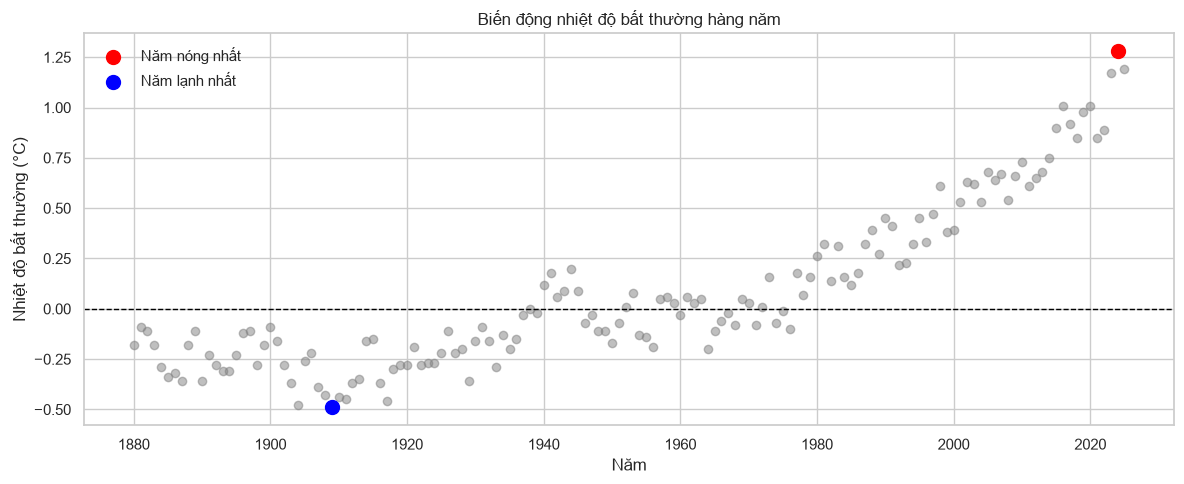

In [8]:
# 4. Câu hỏi 3: Năm nóng nhất, năm lạnh nhất và liên hệ với sự kiện khí hậu lớn
"""
Mục đích: xác định năm cực trị và suy nghĩ về các sự kiện có thể liên quan.
Ta sẽ tìm năm có giá trị annual cao nhất và thấp nhất.
"""

# Năm nóng nhất và lạnh nhất
max_year = df.loc[df['annual'].idxmax(), ['Year', 'annual']]
min_year = df.loc[df['annual'].idxmin(), ['Year', 'annual']]

print('Năm nóng nhất:')
print(max_year)
print('\nNăm lạnh nhất:')
print(min_year)

# Vẽ biểu đồ điểm cho các năm cực trị
plt.figure(figsize=(12, 5))
plt.scatter(df['Year'], df['annual'], alpha=0.5, color='gray')
plt.scatter([max_year['Year']], [max_year['annual']], color='red', s=100, label='Năm nóng nhất')
plt.scatter([min_year['Year']], [min_year['annual']], color='blue', s=100, label='Năm lạnh nhất')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Biến động nhiệt độ bất thường hàng năm')
plt.xlabel('Năm')
plt.ylabel('Nhiệt độ bất thường (°C)')
plt.legend()
plt.tight_layout()
plt.show()


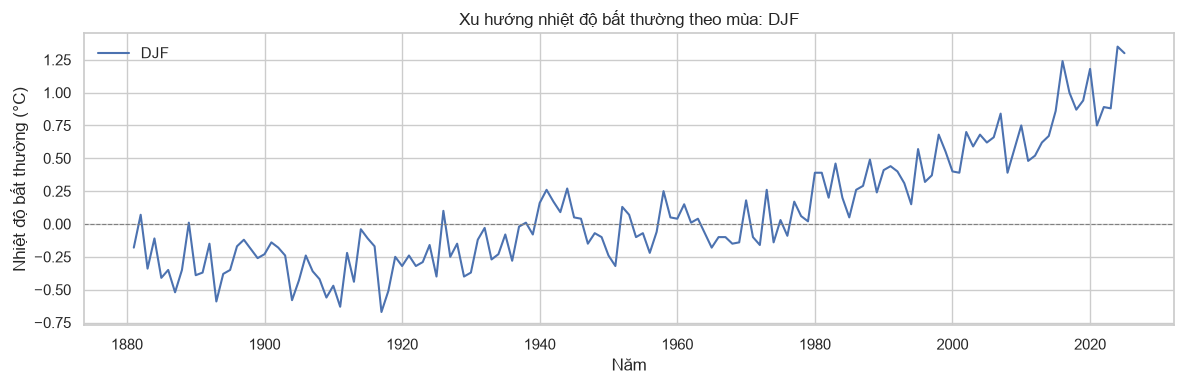

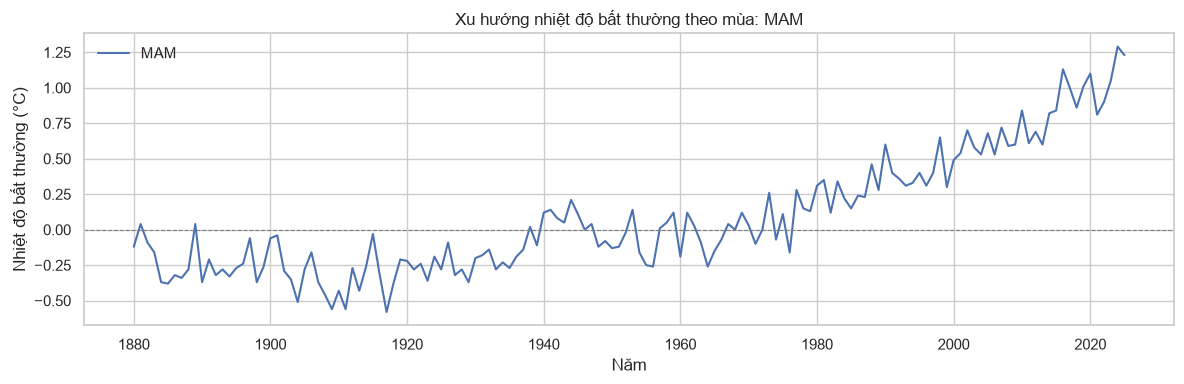

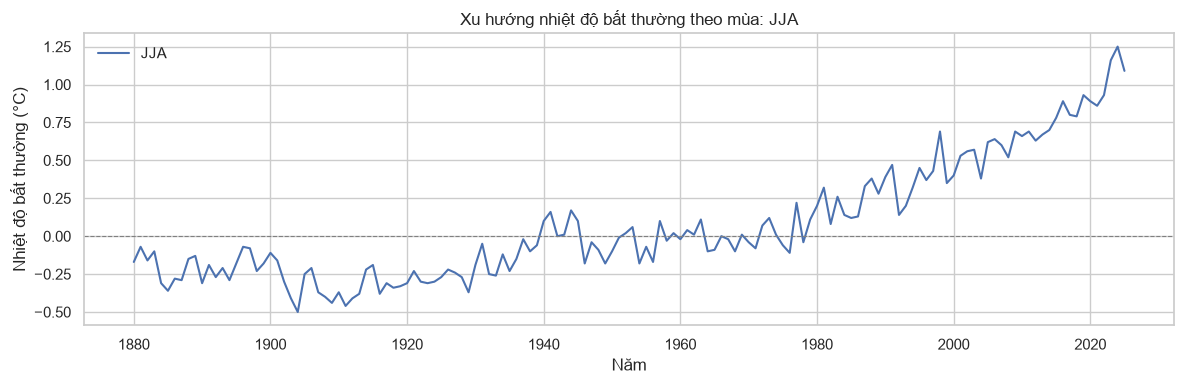

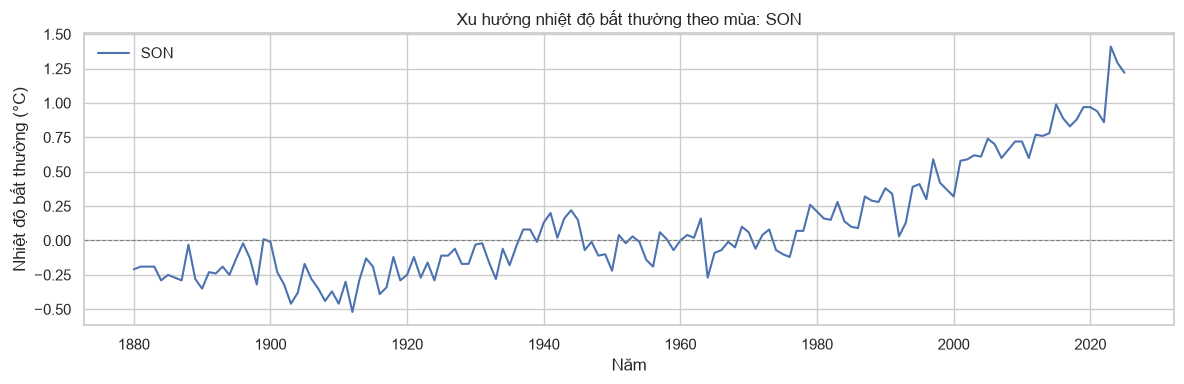

DJF: xu hướng tăng trung bình = 0.008718°C/năm
MAM: xu hướng tăng trung bình = 0.008551°C/năm
JJA: xu hướng tăng trung bình = 0.007960°C/năm
SON: xu hướng tăng trung bình = 0.008039°C/năm


In [10]:
# 5. Câu hỏi 4: So sánh xu hướng theo mùa
"""
Mục đích: kiểm tra xem các mùa có cùng xu hướng tăng mạnh hay không.
Ta tính trung bình theo năm của các mùa DJF, MAM, JJA, SON và vẽ đồ thị.
"""

season_cols = ['DJF', 'MAM', 'JJA', 'SON']
for col in season_cols:
    plt.figure(figsize=(12, 4))
    plt.plot(df['Year'], df[col], label=col)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.title(f'Xu hướng nhiệt độ bất thường theo mùa: {col}')
    plt.xlabel('Năm')
    plt.ylabel('Nhiệt độ bất thường (°C)')
    plt.legend()
    plt.tight_layout()
    plt.show()

# So sánh tốc độ tăng theo mùa bằng hồi quy tuyến tính
for col in season_cols:
    sub = df.dropna(subset=[col])
    X = sub['Year'].to_numpy().reshape(-1, 1)
    y = sub[col].to_numpy()
    model = LinearRegression()
    model.fit(X, y)
    slope = model.coef_[0]
    print(f'{col}: xu hướng tăng trung bình = {slope:.6f}°C/năm')


Độ lệch chuẩn theo thập kỷ:
decade
1880    0.103
1890    0.083
1900    0.136
1910    0.111
1920    0.068
1930    0.090
1940    0.115
1950    0.104
1960    0.084
1970    0.105
1980    0.092
1990    0.118
2000    0.091
2010    0.143
2020    0.175
Name: annual, dtype: float64

Hệ số tương quan giữa Year và annual: 0.8756


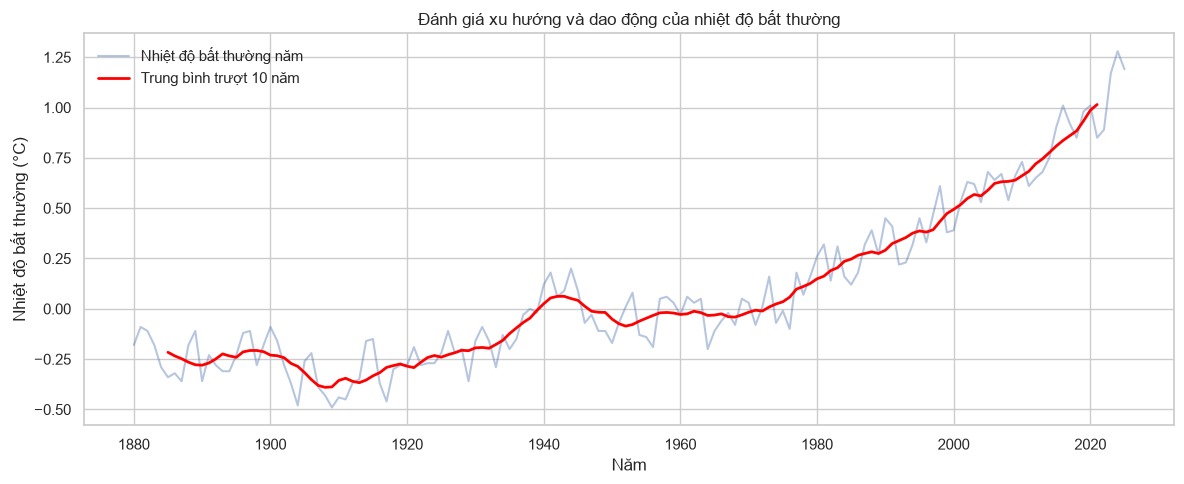


Dự đoán xu hướng bằng hồi quy cho năm 2030: 0.727°C
Kết luận: đến năm 2030, nhiệt độ bất thường dự kiến sẽ nằm trên mức 0°C, tức là khí hậu có xu hướng nóng hơn so với mức chuẩn lịch sử.
Giá trị năm 2025: 1.190°C
Chênh lệch dự đoán 2030 so với 2025: -0.463°C


In [16]:
# 6. Câu hỏi 5: Nhiệt độ bất thường ổn định, tăng đều hay dao động mạnh?
"""
Mục đích: đánh giá xu hướng tổng thể của dữ liệu.
Ta sẽ dùng:
- đường trung bình trượt 10 năm
- độ lệch chuẩn theo thập kỷ
- tổng quan về tính dao động
"""

# Độ lệch chuẩn theo thập kỷ
std_by_decade = df.groupby('decade')['annual'].std()
print('Độ lệch chuẩn theo thập kỷ:')
print(std_by_decade.round(3))

# Tính hệ số tương quan giữa năm và annual
corr = df['Year'].corr(df['annual'])
print(f'\nHệ số tương quan giữa Year và annual: {corr:.4f}')

# Vẽ lại đường xu hướng và đường trung bình trượt 10 năm
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['Year'], df['annual'], alpha=0.4, label='Nhiệt độ bất thường năm')
ax.plot(df['Year'], df['rolling_10'], color='red', linewidth=2, label='Trung bình trượt 10 năm')
ax.set_title('Đánh giá xu hướng và dao động của nhiệt độ bất thường')
ax.set_xlabel('Năm')
ax.set_ylabel('Nhiệt độ bất thường (°C)')
ax.legend()
plt.tight_layout()
plt.show()

# Dự đoán ngắn hạn bằng hồi quy tuyến tính đúng cách
trend_model = LinearRegression()
trend_model.fit(df[['Year']], df['annual'])
future_year = 2030
future_df = pd.DataFrame({'Year': [future_year]})
pred = trend_model.predict(future_df)[0]
print(f'\nDự đoán xu hướng bằng hồi quy cho năm {future_year}: {pred:.3f}°C')

# Phân tích kết quả dự đoán
if pred > 0:
    print(f'Kết luận: đến năm {future_year}, nhiệt độ bất thường dự kiến sẽ nằm trên mức 0°C, tức là khí hậu có xu hướng nóng hơn so với mức chuẩn lịch sử.')
else:
    print(f'Kết luận: đến năm {future_year}, nhiệt độ bất thường dự kiến vẫn thấp hơn 0°C.')

# So sánh với năm 2025
value_2025 = df.loc[df['Year'] == 2025, 'annual'].iloc[0]
print(f'Giá trị năm 2025: {value_2025:.3f}°C')
print(f'Chênh lệch dự đoán 2030 so với 2025: {pred - value_2025:.3f}°C')


## Dự đoán đến năm 2030

Dựa trên xu hướng tăng tuyến tính của dữ liệu từ 1880 đến 2025, mô hình ước tính nhiệt độ bất thường năm 2030 sẽ đạt khoảng **0.73°C**.

Từ kết quả phân cụm, các thập kỷ gần đây (2010s, 2020s) thuộc nhóm có mức nhiệt độ cao nhất, cho thấy xu hướng nóng lên đang tiếp tục mạnh hơn so với giai đoạn đầu thế kỷ.

Từ kết quả phân lớp, tỷ lệ năm "cao" đã tăng rõ và phần lớn các năm sau 1980 đều có giá trị dương. Điều này hỗ trợ dự đoán rằng năm 2030 có khả năng vẫn nằm trong vùng nhiệt độ bất thường dương, tức là nóng hơn mức chuẩn lịch sử.


### Kết luận dự đoán 1
- KMeans chia các thập kỷ thành 3 nhóm chính: nhóm lạnh/lúc đầu, nhóm chuyển tiếp, nhóm nóng gần đây.
- Điều này cho thấy xu hướng nhiệt độ có chuyển từ âm sang dương rõ rệt theo thời gian.
- Các thập kỷ gần đây (2010s, 2020s) nằm trong nhóm có nhiệt độ bất thường cao nhất.


        mean_temp  std_temp  min_temp  max_temp  cluster
decade                                                  
1910       -0.333  0.111360     -0.46     -0.15        1
1900       -0.317  0.136467     -0.49     -0.09        1
1890       -0.241  0.083327     -0.36     -0.11        1
1920       -0.240  0.067659     -0.36     -0.11        1
1880       -0.216  0.102545     -0.36     -0.09        1
1930       -0.123  0.089944     -0.29      0.00        1
1950       -0.047  0.104249     -0.19      0.08        1
1960       -0.031  0.083858     -0.20      0.06        1
1970        0.035  0.104695     -0.10      0.18        1
1940        0.042  0.114969     -0.11      0.20        1
1980        0.247  0.091536      0.12      0.39        0
1990        0.387  0.118044      0.22      0.61        0
2000        0.589  0.090732      0.39      0.68        0
2010        0.808  0.142657      0.61      1.01        2
2020        1.065  0.174786      0.85      1.28        2


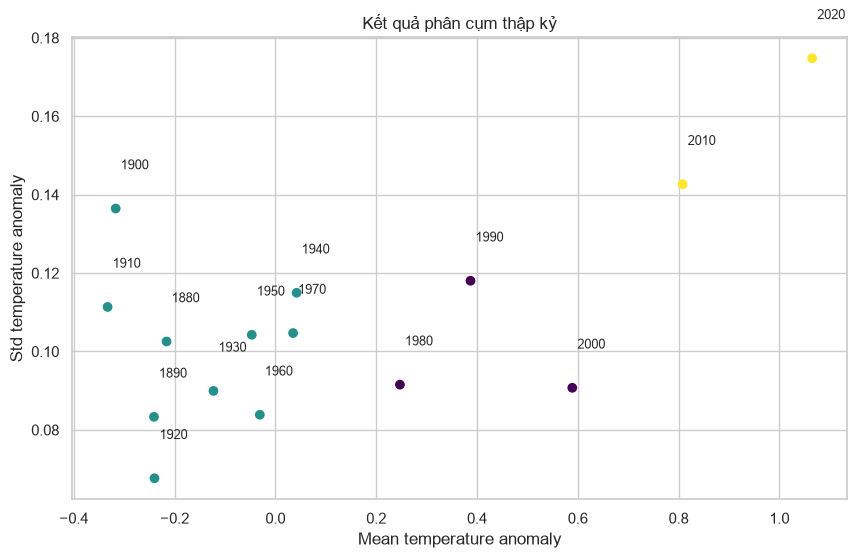

In [13]:
# 7. Dự đoán 1: Phân cụm theo thập kỷ
"""
Mục đích: nhóm các thập kỷ theo xu hướng nhiệt độ gần giống nhau.
Ta dùng các đặc trưng trung bình theo thập kỷ để chạy KMeans.
"""

# Chuẩn bị dữ liệu cho phân cụm
cluster_df = df.groupby('decade').agg(
    mean_temp=('annual', 'mean'),
    std_temp=('annual', 'std'),
    min_temp=('annual', 'min'),
    max_temp=('annual', 'max')
).fillna(0)

# Chuẩn hóa dữ liệu trước khi dùng KMeans
scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)

# Chạy KMeans với 3 cụm (có thể thay đổi nếu cần)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df['cluster'] = kmeans.fit_predict(X_cluster)

print(cluster_df.sort_values('mean_temp'))

# Vẽ biểu đồ phân cụm
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['mean_temp'], cluster_df['std_temp'], c=cluster_df['cluster'], cmap='viridis')
for i, row in cluster_df.iterrows():
    plt.text(row['mean_temp'] + 0.01, row['std_temp'] + 0.01, str(i), fontsize=9)
plt.xlabel('Mean temperature anomaly')
plt.ylabel('Std temperature anomaly')
plt.title('Kết quả phân cụm thập kỷ')
plt.grid(True)
plt.show()


class   cao  thấp  total  ratio_cao
decade                             
1880      0    10     10        0.0
1890      0    10     10        0.0
1900      0    10     10        0.0
1910      0    10     10        0.0
1920      0    10     10        0.0
1930      0    10     10        0.0
1940      6     4     10        0.6
1950      5     5     10        0.5
1960      4     6     10        0.4
1970      6     4     10        0.6
1980     10     0     10        1.0
1990     10     0     10        1.0
2000     10     0     10        1.0
2010     10     0     10        1.0
2020      6     0      6        1.0


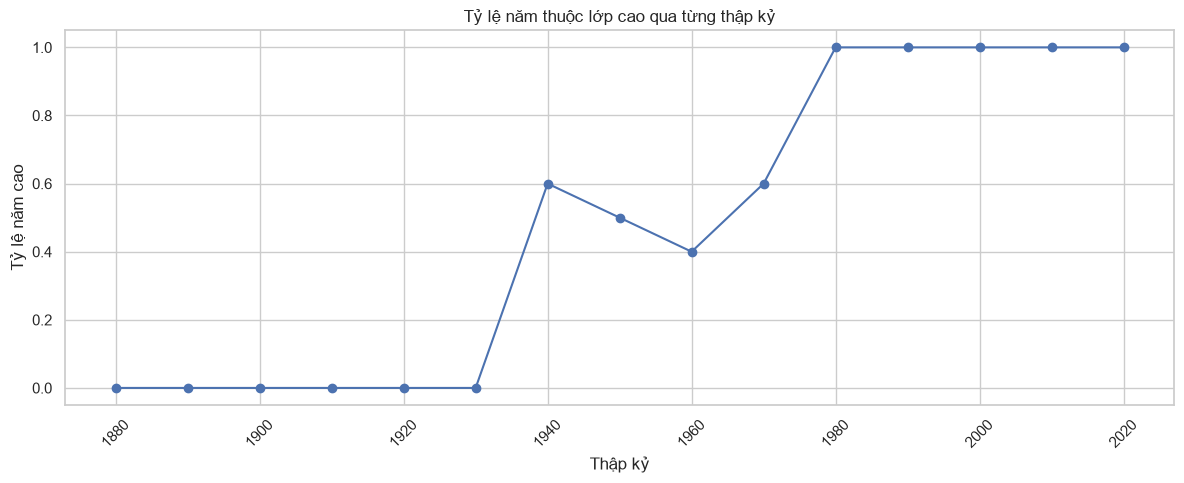

In [14]:
# 8. Dự đoán 2: Phân lớp theo mức nóng/lạnh qua từng thập kỷ
"""
Mục đích: xem tỷ lệ năm thuộc lớp 'cao' (nóng) và 'thấp' (lạnh) qua từng thập kỷ.
Ta dùng ngưỡng 0°C để phân lớp: annual > 0 => 'cao', annual <= 0 => 'thấp'.
"""

# Tạo nhãn lớp cho từng năm
df['class'] = np.where(df['annual'] > 0, 'cao', 'thấp')

# Tính tỷ lệ theo thập kỷ
class_ratio = df.groupby(['decade', 'class']).size().unstack(fill_value=0)
class_ratio['total'] = class_ratio.sum(axis=1)
class_ratio['ratio_cao'] = class_ratio['cao'] / class_ratio['total']
print(class_ratio[['cao', 'thấp', 'total', 'ratio_cao']])

# Vẽ biểu đồ tỷ lệ cao qua từng thập kỷ
plt.figure(figsize=(12, 5))
plt.plot(class_ratio.index, class_ratio['ratio_cao'], marker='o')
plt.title('Tỷ lệ năm thuộc lớp cao qua từng thập kỷ')
plt.xlabel('Thập kỷ')
plt.ylabel('Tỷ lệ năm cao')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


### Kết luận dự đoán 2
- Tỷ lệ năm thuộc lớp "cao" tăng mạnh qua các thập kỷ, đặc biệt từ khoảng 1940 trở đi.
- Từ thập niên 1980 trở về sau, hầu hết các năm đều có giá trị nhiệt độ bất thường dương.
- Điều này cho thấy xu hướng nóng lên đang trở thành hiện tượng ổn định hơn thay vì chỉ xuất hiện rải rác.
